# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Jinne Alberda
* Username: jwalberda
* Student number: S6378439
* Group (AS1, etc.): AS4

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

'\nThis plot shows the intensity of BUNIT in along the vertical line from the pv plot\n'

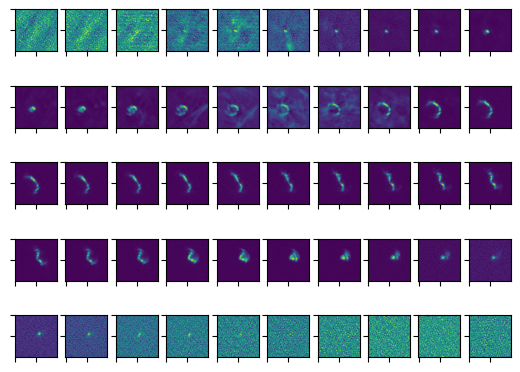

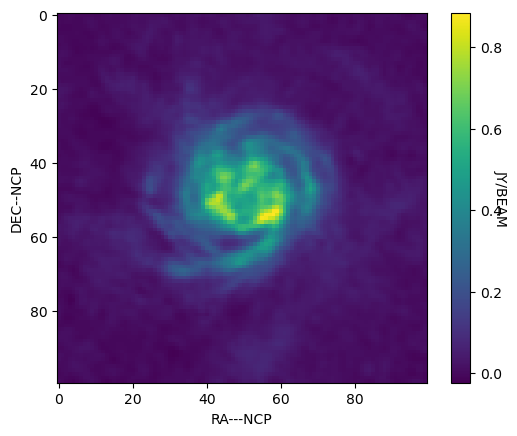

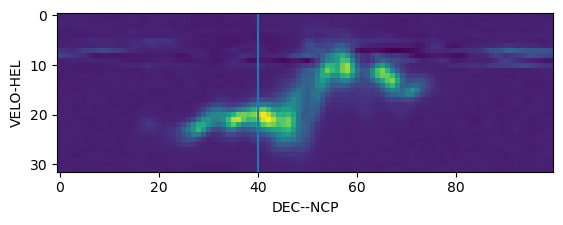

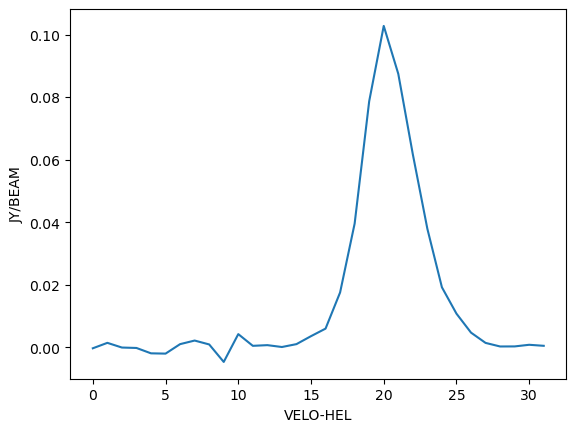

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

fig, axes = plt.subplots(5, 10)

hdul = fits.open('ngc6946.fits')
data = hdul[0].data
hdr = hdul[0].header
subset = data[1:101:2,:,:]
subsubset = subset[7:-11,:,:]
hisum = np.sum(subsubset, axis=0)
pv = subsubset[:, :, 50]
gsp = subsubset[:, 40,50]

for i, ax in enumerate(axes.flat):
    ax.imshow(subset[i])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.figure(2)
plt.imshow(hisum)
plt.xlabel(hdr['CTYPE1'])
plt.ylabel(hdr['CTYPE2'])
cbar = plt.colorbar()
cbar.set_label(hdr['BUNIT'], rotation=270)

plt.figure(3)
plt.imshow(pv)
plt.axvline(40)
plt.xlabel(hdr['CTYPE2'])
plt.ylabel(hdr['CTYPE3'])

plt.figure(4)
plt.plot(np.arange(0,np.size(gsp)),gsp)
plt.xlabel(hdr['CTYPE3'])
plt.ylabel(hdr['BUNIT'])

"""
This plot shows the intensity of BUNIT in along the vertical line from the pv plot
"""

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

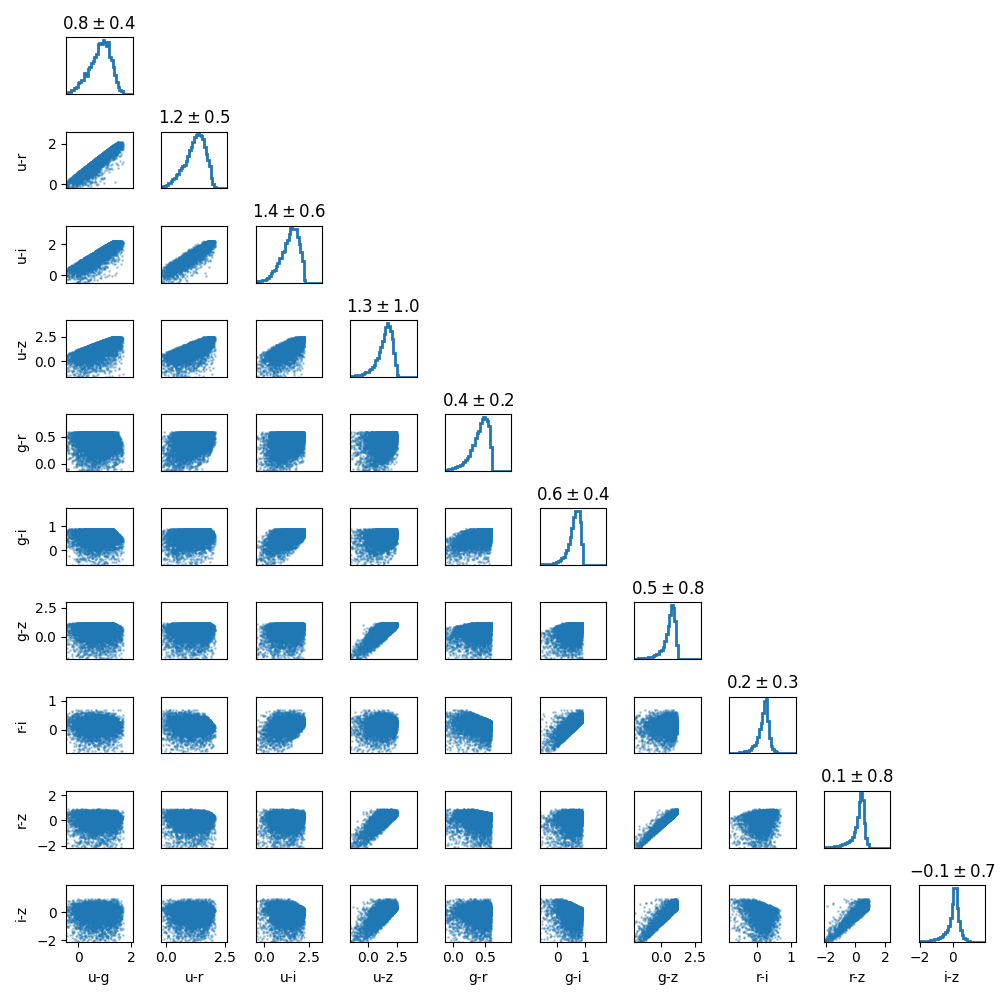
   
**Plot and answer**:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   u       10000 non-null  >f4  
 1   g       10000 non-null  >f4  
 2   r       10000 non-null  >f4  
 3   i       10000 non-null  >f4  
 4   z       10000 non-null  >f4  
dtypes: float32(5)
memory usage: 195.4 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   u       10000 non-null  >f4    
 1   g       10000 non-null  >f4    
 2   r       10000 non-null  >f4    
 3   i       10000 non-null  >f4    
 4   z       10000 non-null  >f4    
 5   u-g     10000 non-null  float32
 6   u-r     10000 non-null  float32
 7   u-i     10000 non-null  float32
 8   u-z     10000 non-null  float32
 9   g-r     10000 non-null  float32
 10  g-i     10000 non-null  float32
 11  g-z     1000

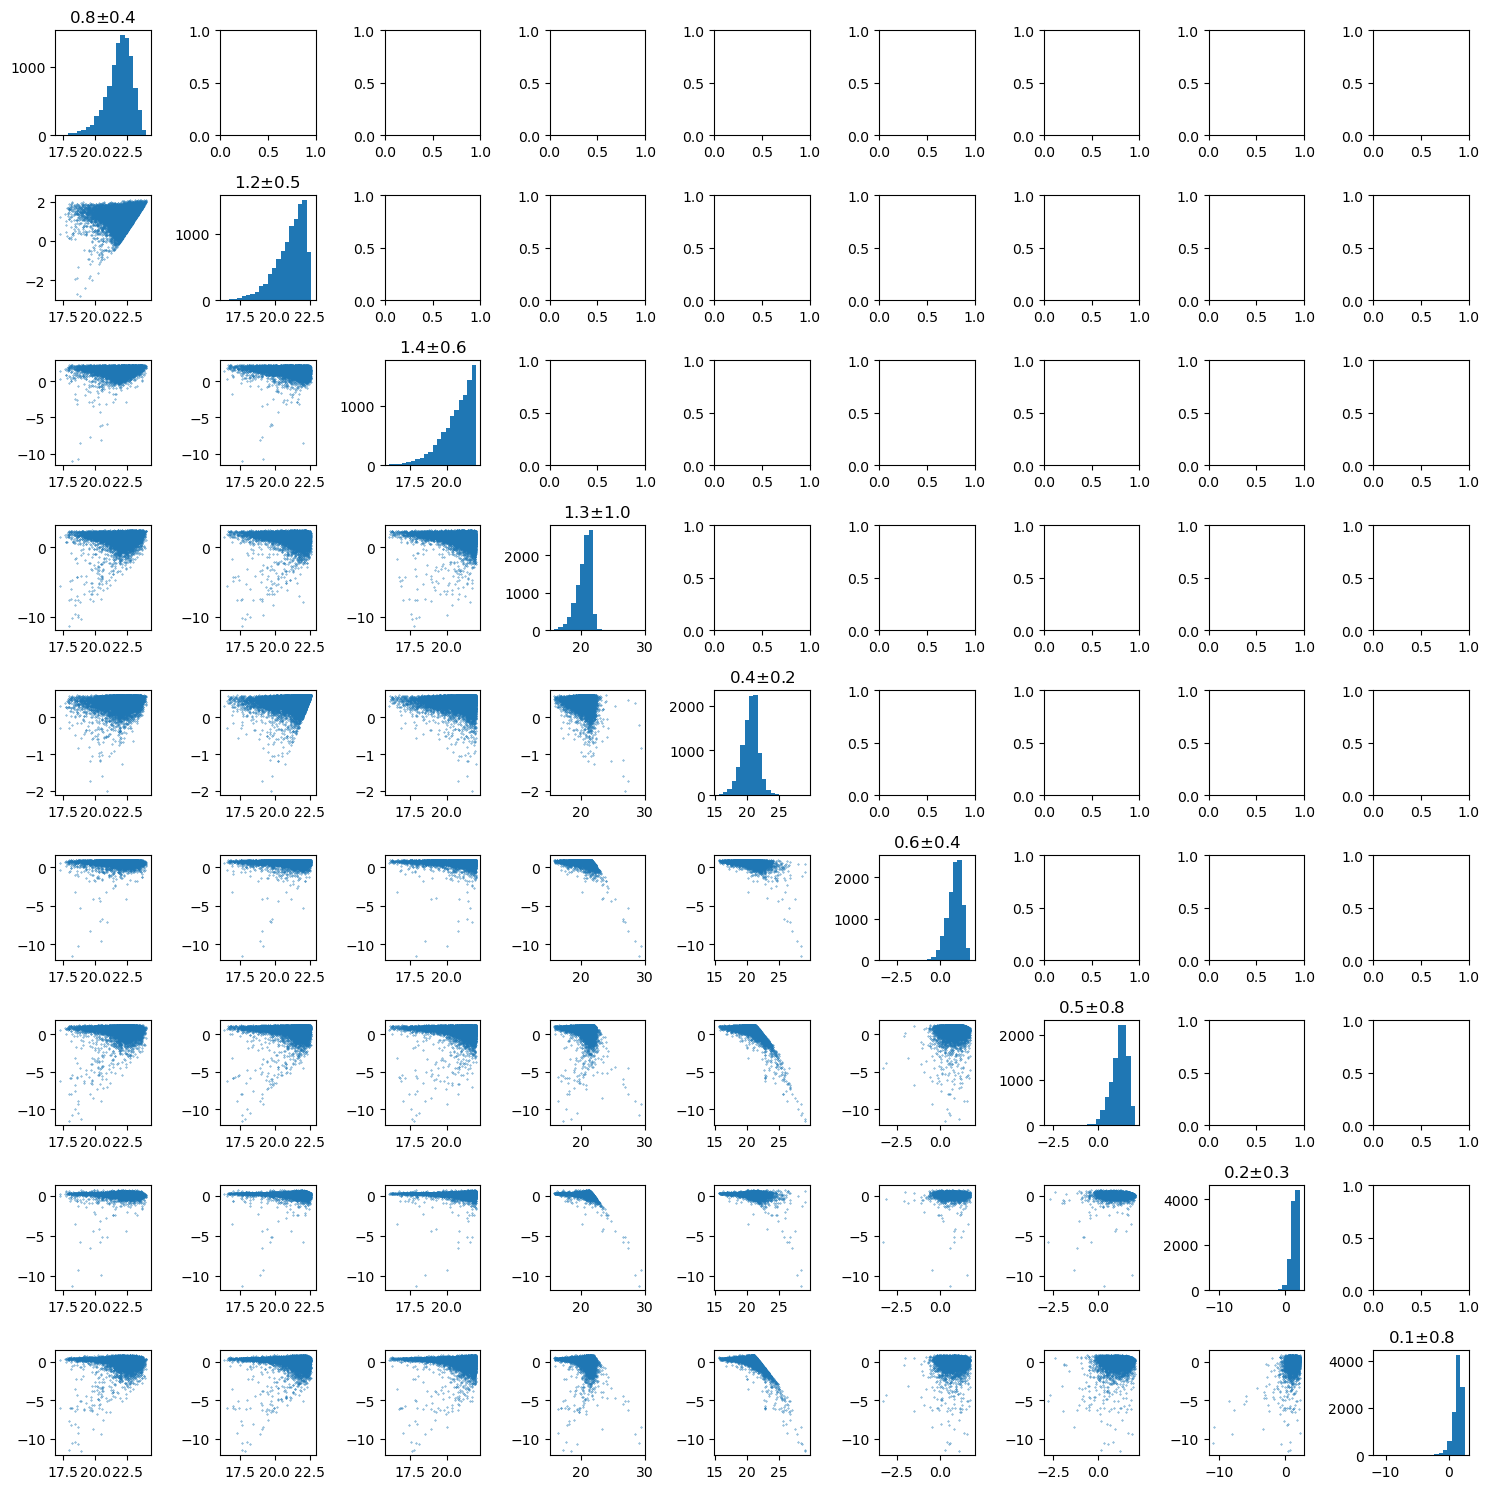

In [4]:
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas
import numpy as np

fit = fits.open('SDSS_DR17_galaxies.fits')
df = pandas.DataFrame(fit[1].data)
del df['ObjID']
df.info()
#dat = {}
means = []
stds = []
filtered = df[df >=0].dropna()
cols = df.columns
for i in cols:
    for j in cols:
        if (i != j) and not (f"{j}-{i}" in df.columns):
            df[f'{i}-{j}'] = df[i] -df[j]
            means.append(float(np.mean(df[f'{i}-{j}'])))
            stds.append(float(np.std(df[f'{i}-{j}'])))
            #dat.update({f'{i}-{j}' : [float(np.mean(df[f'{i}-{j}'])), float(np.std(df[f'{i}-{j}']))]})

fig, axes = plt.subplots(9, 9, figsize=(15,15))
df.info()
for i in range(5, 14):
    for j in range(5, 14):
        ax = axes[i-5, j-5]
        if i==j:
            ax.hist(df.iloc[:, j-5], 20)
            ax.set_title(f'{means[i-5]:.1f}$\\pm${stds[i-5]:.1f}')
        elif j <= i:
            ax.scatter(df.iloc[:, j-5], df.iloc[:, i], s=0.1)
plt.tight_layout()
plt.show()


In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

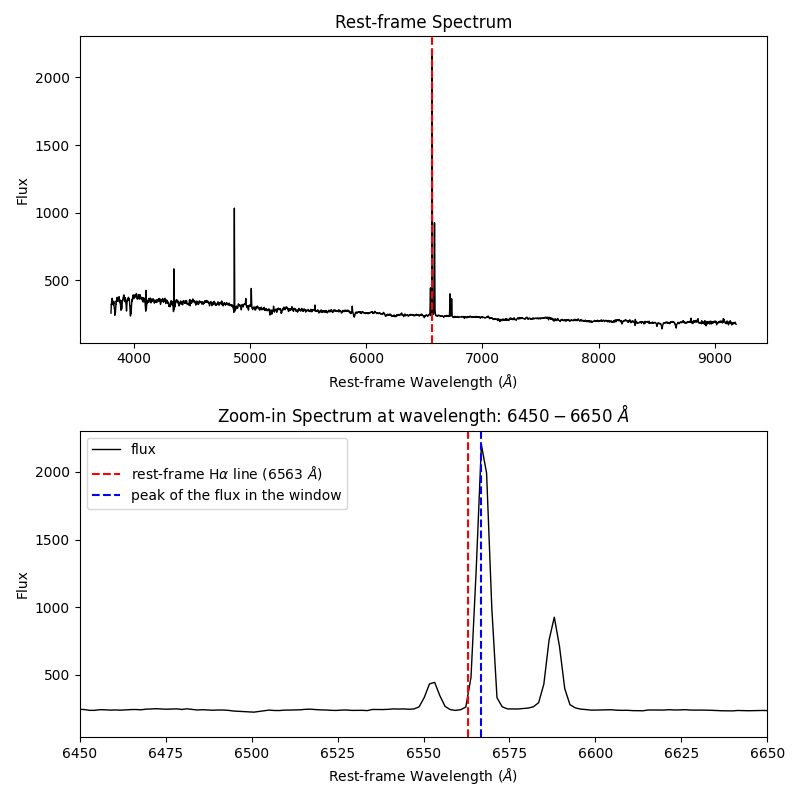

182716.71979274804 300931669.3404


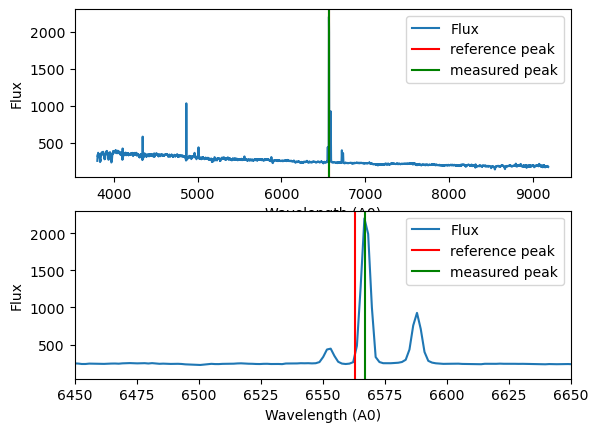

In [6]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from scipy.constants import c
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2)

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
z = 0.0038 + 1
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
sp = SDSS.get_spectra(matches=xid)
data = np.asarray(sp[0][1].data)
flux = []
loglam = []
for i in range(len(data)):
    flux.append(float(data[i][0]))
    loglam.append(float(data[i][1]))
loglam = np.array(loglam)
lam = 10**loglam
wav = lam/z
flux = np.array(flux)

res = ((6567/6563) - 1)*c
print(res, z*c)

ax[0].plot(wav, flux, label='Flux')
ax[1].plot(wav, flux, label='Flux')
ax[1].set_xlim(6450, 6650)
ax[0].axvline(6563, label = 'reference peak', color='r')
ax[0].axvline(6567, label = 'measured peak', color='g')
ax[0].legend()
ax[1].axvline(6563, label = 'reference peak', color='r')
ax[1].axvline(6567, label = 'measured peak', color='g')
ax[0].set_xlabel('Wavelength (A0)')
ax[0].set_ylabel('Flux')
ax[1].set_xlabel('Wavelength (A0)')
ax[1].set_ylabel('Flux')
ax[1].legend()

plt.show()

In [7]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/astropy/visualization/stretch.py:555: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


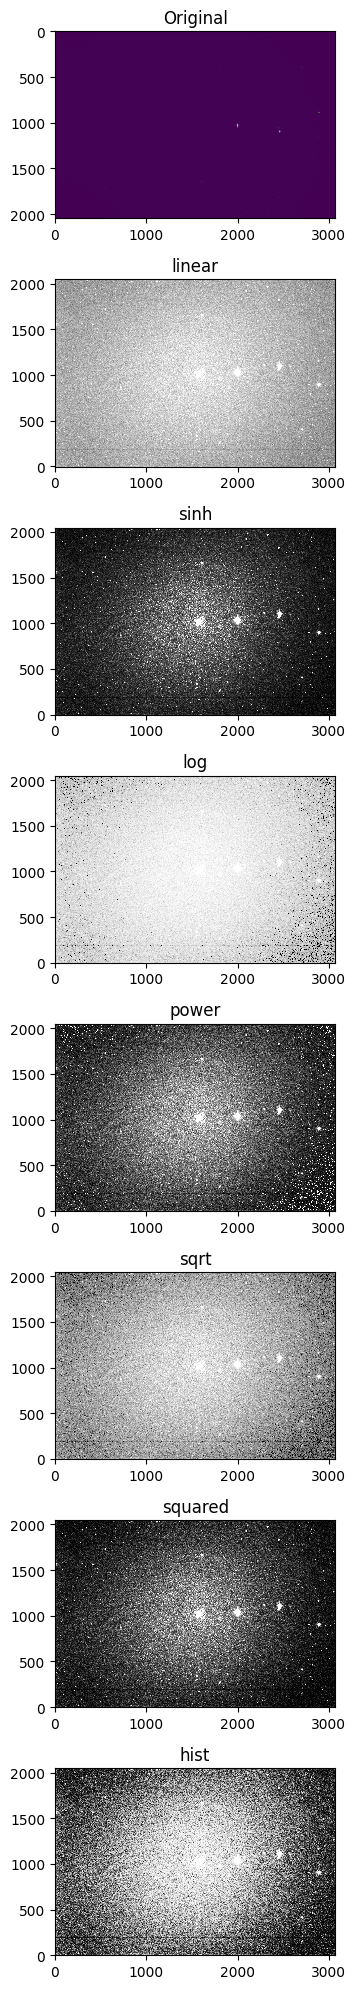

In [2]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,LogStretch, PowerStretch, SqrtStretch, SquaredStretch,HistEqStretch, ZScaleInterval
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

fig, ax = plt.subplots(8, figsize=(20, 20))

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    """
    Displays images with scaling using matplotlib imageshow. Scales are linear, sinh, log, power, sqrt, squared, hist.  Args: (image_data, ax, vmin=None, vmax=None, 
    percentlow=1, percenthigh=99, zscale=False, scale='linear', power=1.5, cmap='gray', **kwargs) 
    """
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)


data = fits.open('20210422_Li_.00000066.fits')[0].data
ax[0].imshow(data)
ax[0].set_title('Original')
imdisplay(data, ax[1], scale='linear')
ax[1].set_title('linear')
imdisplay(data, ax[2], scale='sinh')
ax[2].set_title('sinh')
imdisplay(data, ax[3], scale='log')
ax[3].set_title('log')
imdisplay(data, ax[4], scale='power')
ax[4].set_title('power')
imdisplay(data, ax[5], scale='sqrt')
ax[5].set_title('sqrt')
imdisplay(data, ax[6], scale='squared')
ax[6].set_title('squared')
imdisplay(data, ax[7], scale='hist')
ax[7].set_title('hist')

plt.tight_layout()
plt.show()


In [9]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

Aligning: DATA/i/20210418_Li_.00000033.FIT
Aligning: DATA/i/20210418_Li_.00000034.FIT
Aligning: DATA/i/20210418_Li_.00000035.FIT
Aligning: DATA/i/20210418_Li_.00000036.FIT
Aligning: DATA/i/20210418_Li_.00000037.FIT
Aligning: DATA/i/20210418_Li_.00000038.FIT
Aligning: DATA/i/20210418_Li_.00000039.FIT
Aligning: DATA/i/20210418_Li_.00000040.FIT
Aligning: DATA/i/20210418_Li_.00000041.FIT
Aligning: DATA/i/20210418_Li_.00000042.FIT
Aligning: DATA/i/20210418_Li_.00000043.FIT
Aligning: DATA/i/20210418_Li_.00000044.FIT
Aligning: DATA/i/20210418_Li_.00000045.FIT
Aligning: DATA/i/20210418_Li_.00000046.FIT
(14, 2048, 3072)
(2048, 3072)


/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/astropy/visualization/stretch.py:555: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


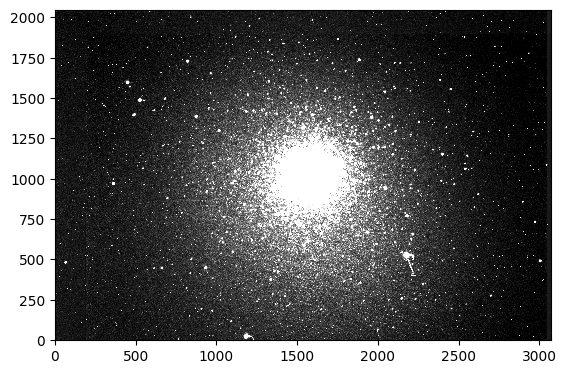

In [1]:
import numpy as np
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,LogStretch, PowerStretch, SqrtStretch, SquaredStretch,HistEqStretch, ZScaleInterval
import matplotlib.pyplot as plt
from astropy.io import fits
from pathlib import Path
import astroalign as aa

datadir = "DATA/i/"
excludes = ['BIAS', 'FLAT', 'DARK']


def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    """
    Displays images with scaling using matplotlib imageshow. Scales are linear, sinh, log, power, sqrt, squared, hist.  Args: (image_data, ax, vmin=None, vmax=None, 
    percentlow=1, percenthigh=99, zscale=False, scale='linear', power=1.5, cmap='gray', **kwargs) 
    """
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)



fig, ax = plt.subplots()

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)


target_im = fits.open(filepaths[6])[0].data

images = []
for filepath in filepaths[1:15]:
    hdulist = fits.open(filepath)
    print(f"Aligning: {filepath}")
    tobealigned_im = hdulist[0].data
    try:
            aligned_im, footprint = aa.register(tobealigned_im,
                                                target_im,
                                                detection_sigma=5.0,
                                                max_control_points=100,
                                                min_area=5)
            images.append(aligned_im)
    except:
        print("Failed")
    hdulist.close()
    
cube = np.stack(images)
print(np.shape(cube))
stacked = np.median(cube, axis=0)
print(np.shape(stacked))

imdisplay(stacked, ax, scale='sinh', percentlow=5, percenthigh=95)
    

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")